# 📓 Pre-Workshop Notebook 4: Cleaning and Processing Research Signals
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [ ]:
# PROFILE SYNC
student_name = "Dr. Evie A. Malaia"
institution = "University of Alabama"
active_notebook = "Notebook 04 — Signal Cleaning and Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with signal data, your main responsibility is making sure the signal you are analyzing is clean and meaningful. AI tools are good at applying mathematical filters, but they sometimes miss edge cases — such as what to do when a recording contains a sudden spike from a movement artifact, or when a calculation produces an unexpected result.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to explain what its filtering steps do in plain language, and to flag any parts of the data that could not be processed cleanly.

---
## 🧠 Part A: Cleaning Raw Recordings
### Topic: Removing Noise, Filtering Signals, and Visualizing Frequency Content

This section introduces the core signal processing steps that transform raw, noisy recordings into clean data ready for analysis.

### 🧭 Activity A.1 — Filtering a Noisy Brain Signal

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a signal processing instructor explaining brain signal cleaning to a biology student. Write a Python script using SciPy and Matplotlib that demonstrates how to clean a noisy brain recording. The script should:
> 1. Generate 5 seconds of a simulated brain signal recorded at 500 measurements per second, combining a realistic 10 Hz brain rhythm, electrical interference at 60 Hz from the building's power supply, and a sudden large spike representing a participant's eye blink or muscle movement.
> 2. Explain in a comment how the Nyquist rule determines what sampling rate is needed to accurately capture this signal.
> 3. Apply a digital bandpass filter to isolate the 10 Hz brain rhythm while removing the 60 Hz electrical noise.
> 4. Add a simple threshold detector that flags and removes the eye blink spike from the recording.
> 5. Display plots of the raw signal, the filtered signal, and the cleaned signal side-by-side.
> Use plain-language comments throughout explaining what each step does biologically and mathematically."

SIMULATED BRAIN-SIGNAL CLEANING

Recording duration: 5.0 seconds
Sampling rate:      500 Hz
Number of samples:  2500

Raw signal contains:
  10 Hz brain rhythm
  60 Hz electrical interference
  Random background noise
  Large eye-blink/muscle artifact

Applied 5-30 Hz bandpass filter.
The 60 Hz power-line component is outside this range and should therefore be strongly reduced.

Threshold: 2.0 signal units
Samples flagged as artifact: 10
Flagged artifact samples were replaced using interpolation from nearby clean data.


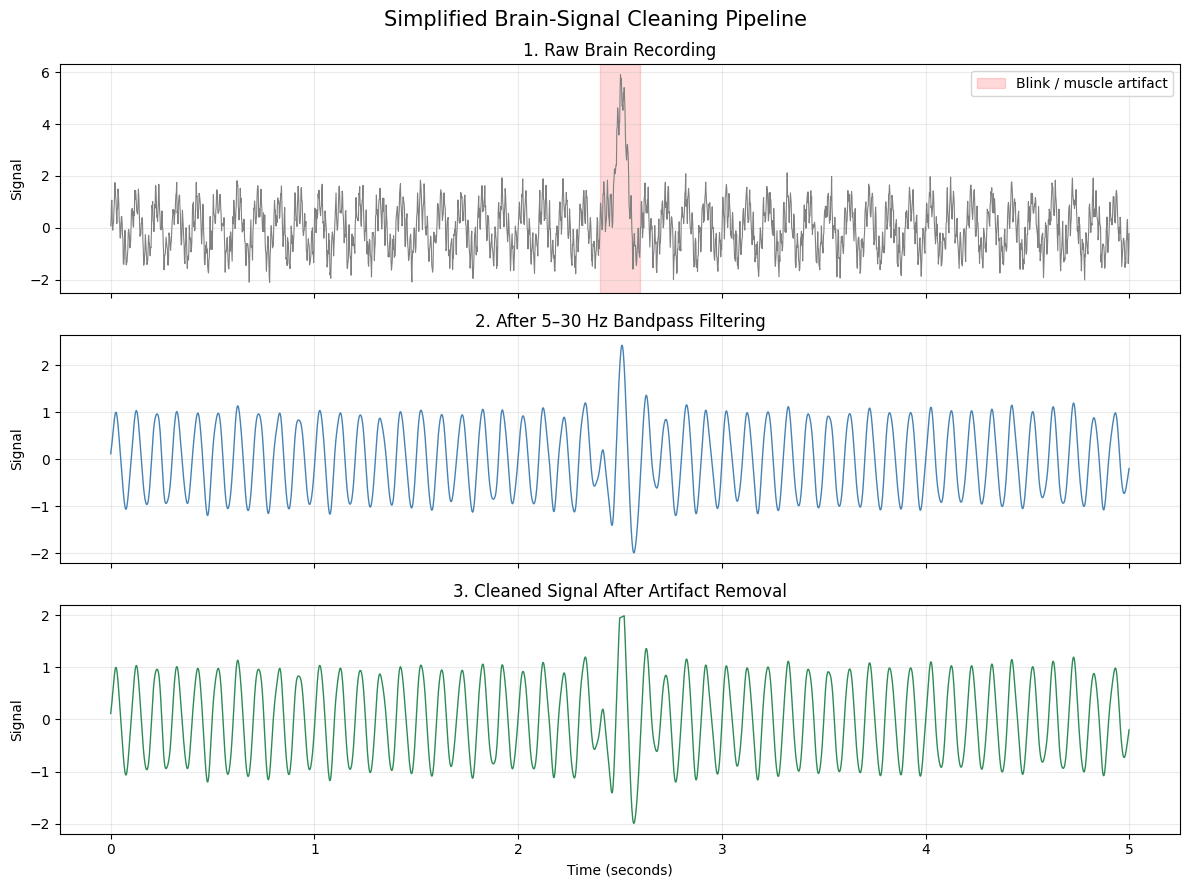


Figure saved as: brain_signal_cleaning.png

SUMMARY

The three stages demonstrate a common signal-processing idea:

RAW:
The recording contains both useful neural activity and unwanted
signals.

FILTERED:
The 5–30 Hz bandpass filter emphasizes the frequency range
containing the simulated 10 Hz brain rhythm and suppresses the
60 Hz electrical interference.

CLEANED:
A simple amplitude threshold identifies the unusually large
blink/muscle artifact, and interpolation replaces those samples
with an estimate based on the surrounding signal.

In real neuroscience research, these decisions should be based
on the properties of the recording and the scientific question.
Filtering and artifact removal can accidentally remove genuine
brain activity if they are applied without care.



In [1]:
# 💻 Activity A.1 — Paste your AI-generated Signal Filtering code here:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


# ============================================================
# Simulated brain-signal cleaning
# ============================================================
#
# We will simulate a recording containing:
#
#   1. A 10 Hz brain rhythm
#   2. 60 Hz electrical interference from the power supply
#   3. Random background noise
#   4. A large sudden artifact representing an eye blink
#      or muscle movement
#
# Then we will:
#
#   1. Apply a bandpass filter to keep the brain rhythm.
#   2. Detect the large artifact using a threshold.
#   3. Replace the artifact with an estimate of the surrounding
#      signal.
#
# This is a simplified demonstration. Real EEG/MEG preprocessing
# usually involves more sophisticated artifact detection and
# filtering methods.
# ============================================================


# ------------------------------------------------------------
# 1. Set up the recording
# ------------------------------------------------------------

duration = 5.0       # Record for 5 seconds
sample_rate = 500    # 500 measurements per second

# Create a time value for every measurement.
time = np.arange(
    0,
    duration,
    1 / sample_rate
)

n_samples = len(time)

print("=" * 65)
print("SIMULATED BRAIN-SIGNAL CLEANING")
print("=" * 65)

print(f"\nRecording duration: {duration} seconds")
print(f"Sampling rate:      {sample_rate} Hz")
print(f"Number of samples:  {n_samples}")


# ------------------------------------------------------------
# Nyquist rule
# ------------------------------------------------------------
#
# The Nyquist rule says that a signal must be sampled at MORE
# THAN twice its highest frequency to represent that frequency
# correctly.
#
# Here our highest intentional frequency is 60 Hz.
#
# Therefore:
#
#     minimum theoretical sampling rate > 2 × 60 Hz
#                                    > 120 Hz
#
# We use 500 Hz, which is comfortably above 120 Hz. This gives
# us many measurements per cycle and allows the 10 Hz rhythm and
# 60 Hz interference to be represented clearly.
#
# If we sampled too slowly, higher-frequency signals could appear
# falsely as lower-frequency signals. This problem is called
# aliasing.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 2. Generate the underlying 10 Hz brain rhythm
# ------------------------------------------------------------

# A 10 Hz oscillation is a simplified representation of rhythmic
# neural activity. Real brain signals are much more complicated
# than a single sine wave.
brain_rhythm = (
    1.0
    * np.sin(2 * np.pi * 10 * time)
)


# ------------------------------------------------------------
# 3. Add 60 Hz electrical interference
# ------------------------------------------------------------

# Electrical equipment and building power systems can introduce
# strong periodic interference into biological recordings.
#
# In the United States, 60 Hz is the typical power-line frequency.
powerline_noise = (
    0.6
    * np.sin(2 * np.pi * 60 * time)
)


# ------------------------------------------------------------
# 4. Add random background noise
# ------------------------------------------------------------

# Real recordings contain many smaller unpredictable fluctuations.
rng = np.random.default_rng(42)

random_noise = rng.normal(
    loc=0,
    scale=0.25,
    size=n_samples
)


# ------------------------------------------------------------
# 5. Create an eye-blink/muscle artifact
# ------------------------------------------------------------

# An eye blink or muscle movement can create a much larger
# voltage change than the neural rhythm we are interested in.
#
# We simulate it as a large Gaussian-shaped spike centered
# around 2.5 seconds.

artifact_center = 2.5

artifact = (
    5.0
    * np.exp(
        -(
            (time - artifact_center) ** 2
        ) / (
            2 * 0.025 ** 2
        )
    )
)


# ------------------------------------------------------------
# 6. Combine everything into the raw recording
# ------------------------------------------------------------

raw_signal = (
    brain_rhythm
    + powerline_noise
    + random_noise
    + artifact
)

print("\nRaw signal contains:")
print("  10 Hz brain rhythm")
print("  60 Hz electrical interference")
print("  Random background noise")
print("  Large eye-blink/muscle artifact")


# ------------------------------------------------------------
# 7. Design a bandpass filter
# ------------------------------------------------------------
#
# We want to keep the 10 Hz brain rhythm while reducing both
# very slow fluctuations and higher-frequency interference.
#
# A 5-30 Hz bandpass is useful for this simplified example:
#
#     frequencies below 5 Hz  -> strongly reduced
#     5-30 Hz                 -> mostly retained
#     frequencies above 30 Hz -> strongly reduced
#
# Since the unwanted electrical interference is at 60 Hz,
# it lies outside this band and is therefore strongly attenuated.
#
# In a real experiment, the appropriate frequency range depends
# on the biological signal and research question.
# ------------------------------------------------------------

low_cutoff = 5
high_cutoff = 30

# Convert frequencies into the form scipy.signal.butter expects.
nyquist_frequency = sample_rate / 2

low = low_cutoff / nyquist_frequency
high = high_cutoff / nyquist_frequency

# Create a 4th-order Butterworth bandpass filter.
b, a = signal.butter(
    4,
    [low, high],
    btype="band"
)


# ------------------------------------------------------------
# 8. Apply the filter
# ------------------------------------------------------------

# filtfilt applies the filter forward and backward.
#
# This is useful for an offline demonstration because it avoids
# introducing the time shift that a one-direction filter can cause.
filtered_signal = signal.filtfilt(
    b,
    a,
    raw_signal
)

print(
    f"\nApplied {low_cutoff}-{high_cutoff} Hz bandpass filter."
)

print(
    "The 60 Hz power-line component is outside this range "
    "and should therefore be strongly reduced."
)


# ------------------------------------------------------------
# 9. Detect the large artifact
# ------------------------------------------------------------

# We use a simple threshold detector.
#
# The idea is:
#   normal neural activity = relatively small amplitude
#   eye blink/muscle artifact = unusually large amplitude
#
# In real research, a fixed amplitude threshold is often too
# simplistic. More advanced methods might use multiple channels,
# independent component analysis, or statistical artifact detection.

threshold = 2.0

artifact_mask = np.abs(filtered_signal) > threshold

n_artifact_samples = np.sum(artifact_mask)

print(
    f"\nThreshold: {threshold:.1f} signal units"
)

print(
    f"Samples flagged as artifact: "
    f"{n_artifact_samples}"
)


# ------------------------------------------------------------
# 10. Remove the detected artifact
# ------------------------------------------------------------

# We do not simply replace the artifact with zero because that
# would create an artificial gap in the recording.
#
# Instead, we estimate what the signal probably looked like by
# interpolating between nearby clean measurements.
cleaned_signal = filtered_signal.copy()

good_samples = ~artifact_mask

# If enough clean samples remain, interpolate across the artifact.
if np.sum(good_samples) > 2:

    cleaned_signal[artifact_mask] = np.interp(
        time[artifact_mask],
        time[good_samples],
        filtered_signal[good_samples]
    )

print(
    "Flagged artifact samples were replaced using "
    "interpolation from nearby clean data."
)


# ------------------------------------------------------------
# 11. Plot the three stages
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9),
    sharex=True
)


# ---- Plot 1: Raw signal ----

axes[0].plot(
    time,
    raw_signal,
    color="gray",
    linewidth=0.8
)

axes[0].set_title(
    "1. Raw Brain Recording"
)

axes[0].set_ylabel(
    "Signal"
)

axes[0].grid(
    alpha=0.25
)

# Highlight the region where the large artifact occurs.
axes[0].axvspan(
    2.4,
    2.6,
    color="red",
    alpha=0.15,
    label="Blink / muscle artifact"
)

axes[0].legend()


# ---- Plot 2: After bandpass filtering ----

axes[1].plot(
    time,
    filtered_signal,
    color="steelblue",
    linewidth=1
)

axes[1].set_title(
    "2. After 5–30 Hz Bandpass Filtering"
)

axes[1].set_ylabel(
    "Signal"
)

axes[1].grid(
    alpha=0.25
)


# ---- Plot 3: Cleaned signal ----

axes[2].plot(
    time,
    cleaned_signal,
    color="seagreen",
    linewidth=1
)

axes[2].set_title(
    "3. Cleaned Signal After Artifact Removal"
)

axes[2].set_xlabel(
    "Time (seconds)"
)

axes[2].set_ylabel(
    "Signal"
)

axes[2].grid(
    alpha=0.25
)


plt.suptitle(
    "Simplified Brain-Signal Cleaning Pipeline",
    fontsize=15
)

plt.tight_layout()

# Save a high-resolution copy of the figure.
plt.savefig(
    "brain_signal_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nFigure saved as: brain_signal_cleaning.png"
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)

print(
    """
The three stages demonstrate a common signal-processing idea:

RAW:
The recording contains both useful neural activity and unwanted
signals.

FILTERED:
The 5–30 Hz bandpass filter emphasizes the frequency range
containing the simulated 10 Hz brain rhythm and suppresses the
60 Hz electrical interference.

CLEANED:
A simple amplitude threshold identifies the unusually large
blink/muscle artifact, and interpolation replaces those samples
with an estimate based on the surrounding signal.

In real neuroscience research, these decisions should be based
on the properties of the recording and the scientific question.
Filtering and artifact removal can accidentally remove genuine
brain activity if they are applied without care.
"""
)


### 🧭 Activity A.2 — Visualizing How Signals Change Over Time

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data visualization instructor. Write a Python script using SciPy and Matplotlib that shows how to create a time-frequency plot (spectrogram) of a brain signal. The script should:
> 1. Generate a signal that shifts from a slow rhythm (8 Hz, representing a resting brain state) for the first 2 seconds, then transitions to a faster rhythm (25 Hz, representing an active brain state) for the final 3 seconds.
> 2. Compute a spectrogram of this signal that shows how its frequency content changes over time.
> 3. Display the spectrogram with a color scale showing signal strength, with time on the horizontal axis and frequency on the vertical axis.
> Add plain-language comments explaining what a spectrogram reveals that a simple time-series plot cannot."

SIMULATED TIME-FREQUENCY ANALYSIS

Recording duration: 5 seconds
Sampling rate:      500 Hz
Number of samples:  2500


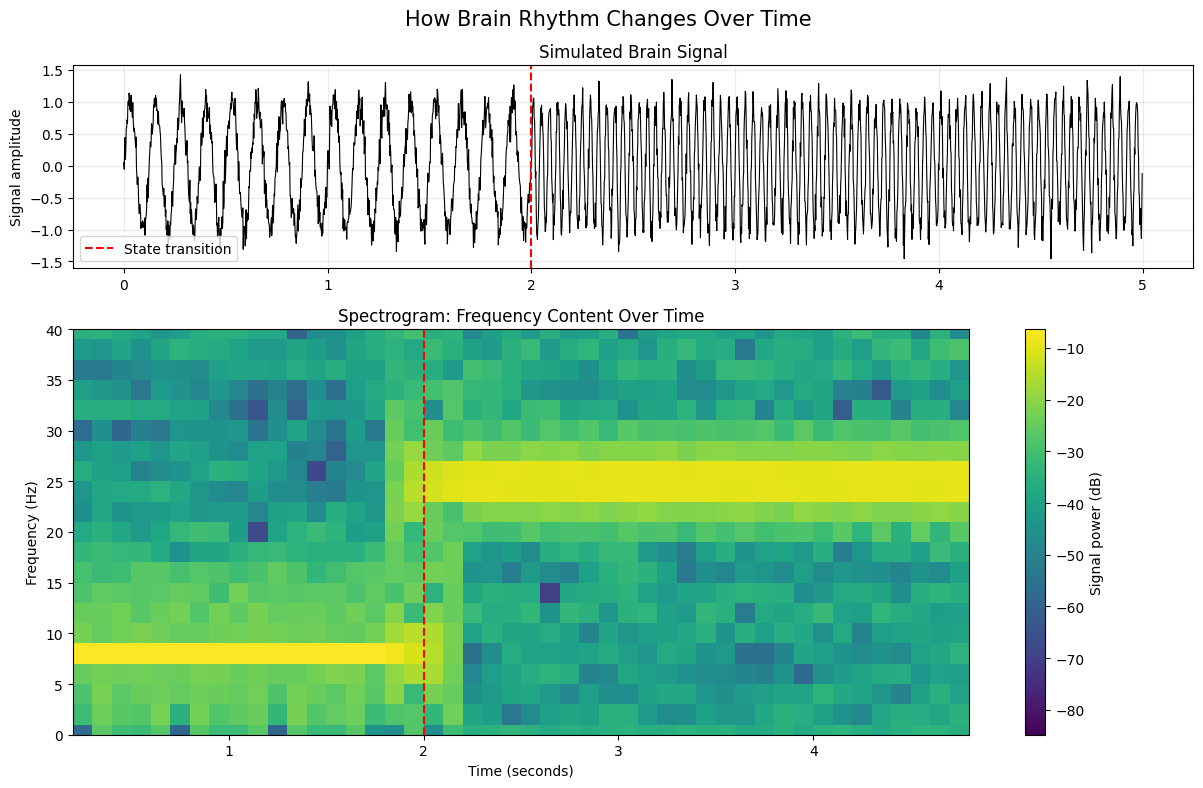


Figure saved as: brain_spectrogram.png

HOW TO READ THE SPECTROGRAM

During the first 2 seconds:
    Look for a bright horizontal band near 8 Hz.
    This represents the simulated resting rhythm.

After 2 seconds:
    The strongest band moves upward to approximately 25 Hz.
    This represents the simulated active brain state.

The important advantage of the spectrogram is that it shows
BOTH frequency and time.

A simple time-series plot can show that the waveform changes,
but it does not directly show which frequencies are responsible
for that change.

In real neuroscience research, this type of visualization can
help researchers investigate changes in neural rhythms during
tasks, sensory stimulation, sleep, or different behavioral
states.



In [2]:
# 💻 Activity A.2 — Paste your AI-generated Spectrogram code here:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


# ============================================================
# Time-frequency analysis of a simulated brain signal
# ============================================================
#
# A normal time-series plot tells us:
#
#       "How does the signal's voltage change over time?"
#
# A spectrogram answers a different question:
#
#       "Which frequencies are present at each point in time?"
#
# This is useful for brain recordings because neural activity
# can change its dominant rhythm while an experiment is running.
#
# In this example:
#
#   0-2 seconds -> 8 Hz rhythm (simulated resting state)
#   2-5 seconds -> 25 Hz rhythm (simulated active state)
#
# A time-series plot shows the waveform changing, but it can be
# difficult to tell exactly when its frequency changes.
#
# The spectrogram makes that transition visible as a change in
# the location of the strongest signal along the frequency axis.
# ============================================================


# ------------------------------------------------------------
# 1. Create the simulated recording
# ------------------------------------------------------------

sample_rate = 500       # 500 measurements per second
duration = 5            # 5-second recording

# Create one time value for every measurement.
time = np.arange(
    0,
    duration,
    1 / sample_rate
)

print("=" * 65)
print("SIMULATED TIME-FREQUENCY ANALYSIS")
print("=" * 65)

print(f"\nRecording duration: {duration} seconds")
print(f"Sampling rate:      {sample_rate} Hz")
print(f"Number of samples:  {len(time)}")


# ------------------------------------------------------------
# 2. Create the two brain states
# ------------------------------------------------------------

# First state: an 8 Hz rhythm.
#
# Eight cycles occur every second. We use a sine wave as a
# simple mathematical representation of rhythmic neural activity.
resting_signal = np.sin(
    2 * np.pi * 8 * time
)


# Second state: a 25 Hz rhythm.
#
# Twenty-five cycles occur every second. This represents our
# simplified "active" brain state.
active_signal = np.sin(
    2 * np.pi * 25 * time
)


# ------------------------------------------------------------
# 3. Combine the two states
# ------------------------------------------------------------

# Start with the resting rhythm.
brain_signal = resting_signal.copy()

# Find all measurements occurring at 2 seconds or later.
active_period = time >= 2

# Replace those measurements with the faster rhythm.
brain_signal[active_period] = active_signal[active_period]


# Add a small amount of random background noise.
#
# Real brain recordings contain many sources of variation, so
# the signal is rarely a perfectly clean sine wave.
rng = np.random.default_rng(42)

noise = rng.normal(
    0,
    0.15,
    size=len(time)
)

brain_signal += noise


# ------------------------------------------------------------
# 4. Calculate the spectrogram
# ------------------------------------------------------------

# The spectrogram divides the recording into short overlapping
# windows and calculates the frequency content of each window.
#
# Mathematically, this is based on repeated Fourier transforms.
#
# Because each window is short, we can see how the frequency
# content changes through time rather than getting only one
# frequency spectrum for the entire recording.
frequencies, times, power = signal.spectrogram(
    brain_signal,
    fs=sample_rate,
    nperseg=250,
    noverlap=200,
    scaling="density"
)


# Convert power to decibels.
#
# Larger values indicate stronger signal power at that
# particular frequency and time.
power_db = 10 * np.log10(
    power + 1e-12
)


# ------------------------------------------------------------
# 5. Create the visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [1, 2]}
)


# ------------------------------------------------------------
# Top: ordinary time-series plot
# ------------------------------------------------------------

axes[0].plot(
    time,
    brain_signal,
    color="black",
    linewidth=0.8
)

axes[0].axvline(
    2,
    color="red",
    linestyle="--",
    label="State transition"
)

axes[0].set_title(
    "Simulated Brain Signal"
)

axes[0].set_ylabel(
    "Signal amplitude"
)

axes[0].legend()

axes[0].grid(
    alpha=0.25
)


# ------------------------------------------------------------
# Bottom: spectrogram
# ------------------------------------------------------------

# pcolormesh displays the frequency power as colors.
#
# Horizontal axis = time
# Vertical axis   = frequency
# Color           = signal strength
#
# The strongest colors around 8 Hz during the first 2 seconds
# represent the simulated resting rhythm.
#
# After 2 seconds, the strong band moves to 25 Hz, representing
# our simulated transition to the active state.
mesh = axes[1].pcolormesh(
    times,
    frequencies,
    power_db,
    shading="auto",
    cmap="viridis"
)

axes[1].set_title(
    "Spectrogram: Frequency Content Over Time"
)

axes[1].set_xlabel(
    "Time (seconds)"
)

axes[1].set_ylabel(
    "Frequency (Hz)"
)

# We are interested in frequencies up to 40 Hz for this example.
axes[1].set_ylim(
    0,
    40
)

axes[1].axvline(
    2,
    color="red",
    linestyle="--"
)


# Add a color bar explaining what the colors mean.
colorbar = fig.colorbar(
    mesh,
    ax=axes[1]
)

colorbar.set_label(
    "Signal power (dB)"
)


plt.suptitle(
    "How Brain Rhythm Changes Over Time",
    fontsize=15
)

plt.tight_layout()


# Save the figure for use in a report or presentation.
plt.savefig(
    "brain_spectrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nFigure saved as: brain_spectrogram.png"
)


# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("HOW TO READ THE SPECTROGRAM")
print("=" * 65)

print(
    """
During the first 2 seconds:
    Look for a bright horizontal band near 8 Hz.
    This represents the simulated resting rhythm.

After 2 seconds:
    The strongest band moves upward to approximately 25 Hz.
    This represents the simulated active brain state.

The important advantage of the spectrogram is that it shows
BOTH frequency and time.

A simple time-series plot can show that the waveform changes,
but it does not directly show which frequencies are responsible
for that change.

In real neuroscience research, this type of visualization can
help researchers investigate changes in neural rhythms during
tasks, sensory stimulation, sleep, or different behavioral
states.
"""
)


### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the filtered outputs from Activity A.1, what happened to the 60 Hz noise and the blink spike? Did the filter affect the brain rhythm you were trying to preserve? - The 60 Hz electrical noise is outside passband, removed. The large blink or muscle spike was not completely removed by the filter; the threshold detector identified the unusually large signal and replaced it using interpolation.

The filter was designed to preserve the 10 Hz brain rhythm, so that rhythm remained visible. Filtering can change the shape or amplitude of a real brain signal - we need to choose filter settings based on the frequencies they actually want to study.

* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 15, 18, 19, and 21** from your Reference Guide. Explain in plain language what a spectrogram shows compared to a simple plot of voltage over time. - gives time-frequency resolution, instead of just time.

---

## 💻 Part B: Writing Workflows That Handle Problems Gracefully
### Topic: Error Handling and Protecting Your Original Data

This section introduces two principles that make research workflows more reliable and reproducible: handling unexpected errors without crashing, and never overwriting your original data.

### 🧭 Activity B.1 — Building a Workflow That Does Not Crash

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software reliability instructor. Write a Python script that demonstrates how to build an analysis workflow that handles unexpected data problems gracefully, without crashing the entire analysis. The script should:
> 1. Create a dataset of measurements that intentionally includes some problematic values — such as a zero where a division will be performed, or a missing value.
> 2. Write an analysis loop that processes each measurement, using an error-handling structure (try/except/finally) to catch and log any problems it encounters, rather than stopping immediately.
> 3. Demonstrate that when one measurement causes a problem, the workflow logs what went wrong and continues processing the remaining measurements.
> 4. Show clearly that the original dataset was not modified — the results are saved to a new, separate output.
> Use plain-language comments explaining why this approach is important for long analysis runs on large datasets."

In [3]:
# 💻 Activity B.1 — Paste your AI-generated Error Handling code here:
import numpy as np


# ============================================================
# Reliable analysis with error handling
# ============================================================
#
# Imagine that these values came from a laboratory instrument.
# Most measurements are valid, but real research datasets can
# contain unexpected problems such as:
#
#   - missing values
#   - zeros where a denominator was expected
#   - invalid measurements
#   - corrupted records
#
# A long analysis should not necessarily stop because of one
# problematic measurement.
#
# Instead, we can:
#
#   1. Detect the problem.
#   2. Record what happened.
#   3. Skip the problematic measurement.
#   4. Continue analyzing the remaining data.
#
# We also keep the original dataset unchanged. Analysis results
# are stored in a separate output array.
# ============================================================


# ------------------------------------------------------------
# 1. Create an example dataset
# ------------------------------------------------------------

# Each row represents one measurement.
#
# Column 0 = numerator
# Column 1 = denominator
#
# The analysis will calculate:
#
#       numerator / denominator
#
# We intentionally include:
#
#   - a zero denominator
#   - a missing value (NaN)
#
# to demonstrate how the workflow handles bad data.

original_data = np.array([
    [10.0, 2.0],
    [15.0, 3.0],
    [20.0, 4.0],
    [25.0, 0.0],      # Problem: division by zero
    [30.0, 5.0],
    [np.nan, 6.0],    # Problem: missing numerator
    [40.0, 8.0],
    [45.0, 9.0],
    [50.0, 10.0],
    [60.0, 12.0]
])


# Make a copy so we can later prove that the original data
# has not been modified.
original_backup = original_data.copy()


print("=" * 65)
print("RELIABLE DATA-ANALYSIS DEMONSTRATION")
print("=" * 65)

print("\nOriginal dataset:")
print(original_data)


# ------------------------------------------------------------
# 2. Create a separate output for analysis results
# ------------------------------------------------------------

# We use NaN as a placeholder for measurements that could not
# be analyzed.
#
# Most importantly, this is a NEW array. We are not changing
# original_data while performing the analysis.
results = np.full(
    len(original_data),
    np.nan
)


# A separate list will contain human-readable error messages.
error_log = []


# ------------------------------------------------------------
# 3. Process every measurement
# ------------------------------------------------------------

print("\nStarting analysis...\n")

for index, row in enumerate(original_data):

    print(
        f"Processing measurement {index + 1}..."
    )

    try:
        # Extract the numerator and denominator.
        numerator = row[0]
        denominator = row[1]

        # ----------------------------------------------------
        # Check for missing values explicitly.
        # ----------------------------------------------------

        if np.isnan(numerator) or np.isnan(denominator):
            raise ValueError(
                "missing value encountered"
            )

        # ----------------------------------------------------
        # Check for an invalid denominator.
        # ----------------------------------------------------
        #
        # Mathematically, division by zero is undefined.
        # We detect it ourselves so that the problem becomes
        # a clear, understandable error message.
        if denominator == 0:
            raise ZeroDivisionError(
                "denominator is zero"
            )

        # ----------------------------------------------------
        # Perform the actual analysis.
        # ----------------------------------------------------

        result = numerator / denominator

        # Store the result in the SEPARATE output array.
        results[index] = result

        print(
            f"  SUCCESS: result = {result:.3f}"
        )

    except ZeroDivisionError as error:

        # Record the problem rather than stopping the entire
        # analysis.
        message = (
            f"Measurement {index + 1}: "
            f"division problem - {error}"
        )

        error_log.append(message)

        print(
            f"  ERROR: {message}"
        )

    except ValueError as error:

        # Missing or otherwise invalid data ends up here.
        message = (
            f"Measurement {index + 1}: "
            f"invalid data - {error}"
        )

        error_log.append(message)

        print(
            f"  ERROR: {message}"
        )

    except Exception as error:

        # This catches other unexpected problems.
        #
        # In production research software, it is useful to log
        # unexpected errors so they can be investigated rather
        # than silently ignoring them.
        message = (
            f"Measurement {index + 1}: "
            f"unexpected error - {error}"
        )

        error_log.append(message)

        print(
            f"  ERROR: {message}"
        )

    finally:

        # The finally block runs whether the measurement
        # succeeded or failed.
        #
        # It is useful for actions that should always happen,
        # such as writing a progress message, closing a file,
        # or releasing another resource.
        print(
            f"  Finished measurement {index + 1}."
        )


# ------------------------------------------------------------
# 4. Display the analysis results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("ANALYSIS RESULTS")
print("=" * 65)

print(
    "\nResults are stored separately from the original data:"
)

print(results)


# ------------------------------------------------------------
# 5. Display the error log
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("ERROR LOG")
print("=" * 65)

if error_log:

    for message in error_log:
        print(
            f"  {message}"
        )

else:
    print("No errors were encountered.")


# ------------------------------------------------------------
# 6. Prove that the original dataset was not changed
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CHECKING ORIGINAL DATA")
print("=" * 65)

# np.array_equal normally treats NaN values as unequal, so we
# use equal_nan=True for this comparison.
original_unchanged = np.array_equal(
    original_data,
    original_backup,
    equal_nan=True
)

print(
    f"\nWas the original dataset modified? "
    f"{not original_unchanged}"
)

print(
    f"Original dataset unchanged: "
    f"{original_unchanged}"
)

if original_unchanged:
    print(
        "\nThe original data is intact."
    )

print(
    "\nThe calculated results were placed in a separate "
    "output array."
)


# ------------------------------------------------------------
# 7. Final summary
# ------------------------------------------------------------

successful = np.sum(
    ~np.isnan(results)
)

failed = len(results) - successful

print("\n" + "=" * 65)
print("WORKFLOW SUMMARY")
print("=" * 65)

print(
    f"\nMeasurements processed: {len(original_data)}"
)

print(
    f"Successful analyses:    {successful}"
)

print(
    f"Problematic measurements: {failed}"
)

print(
    """
The important lesson is that an error in one measurement does
not have to terminate the entire research workflow.

The try/except structure lets the program identify the problem,
log useful information about it, and continue with the remaining
measurements.

The finally block runs after every measurement regardless of
whether it succeeded or failed.

Keeping the original dataset separate from the analysis results
also protects the raw data. This is important for reproducibility:
researchers can always return to the original measurements and
rerun the analysis with improved error-handling or analysis code.

For a long analysis involving thousands or millions of records,
this approach can prevent a single corrupted or unexpected
measurement from wasting hours of computation.
"""
)


RELIABLE DATA-ANALYSIS DEMONSTRATION

Original dataset:
[[10.  2.]
 [15.  3.]
 [20.  4.]
 [25.  0.]
 [30.  5.]
 [nan  6.]
 [40.  8.]
 [45.  9.]
 [50. 10.]
 [60. 12.]]

Starting analysis...

Processing measurement 1...
  SUCCESS: result = 5.000
  Finished measurement 1.
Processing measurement 2...
  SUCCESS: result = 5.000
  Finished measurement 2.
Processing measurement 3...
  SUCCESS: result = 5.000
  Finished measurement 3.
Processing measurement 4...
  ERROR: Measurement 4: division problem - denominator is zero
  Finished measurement 4.
Processing measurement 5...
  SUCCESS: result = 6.000
  Finished measurement 5.
Processing measurement 6...
  ERROR: Measurement 6: invalid data - missing value encountered
  Finished measurement 6.
Processing measurement 7...
  SUCCESS: result = 5.000
  Finished measurement 7.
Processing measurement 8...
  SUCCESS: result = 5.000
  Finished measurement 8.
Processing measurement 9...
  SUCCESS: result = 5.000
  Finished measurement 9.
Processing mea

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What happened when the workflow encountered a problematic value? Did it stop, or did it continue? How was the problem recorded? - The try/except structure let the program identify the problem, log useful information about it, and continue with the remaining measurements.

* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 45, 47, and 50** from your Reference Guide. Explain in plain language why a scientific workflow should never modify the original raw data files, even if it finds something wrong with them.- Keeping the original dataset separate from the analysis results
protects the raw data. This is important for reproducibility:
researchers can always return to the original measurements and
rerun the analysis with improved error-handling or analysis code.

---

## 📑 What Comes Next

Notebook 5 introduces machine learning and pattern recognition — how computers can learn to identify behavioral states or intentions from brain signal patterns.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 15 — Artifact removal | [ Enter Cell ID ] |
| Neuroscience | Concept 18 — Spectrogram | [ Enter Cell ID ] |
| Neuroscience | Concept 19 — Nyquist rule | [ Enter Cell ID ] |
| Computing | Concept 45 — Software libraries | [ Enter Cell ID ] |
| Computing | Concept 47 — Error handling | [ Enter Cell ID ] |
| Computing | Concept 50 — Protecting original data | [ Enter Cell ID ] |
